# Anàlisi Exploratori de Dades (EDA)
## IDSS — Detecció del Risc d'Abandonament Escolar

Aquest notebook realitza un **anàlisi exploratori** del conjunt de dades `student_final.csv` per al projecte IDSS de detecció d'abandonament escolar.

### Objectius de l'EDA:
1. **Comprendre l'estructura** del dataset i verificar la qualitat de les dades preprocessades.
2. **Analitzar la variable objectiu** (`dropout`) i el seu desequilibri.
3. **Identificar quines variables discriminen realment** entre estudiants que abandonen i els que no.
4. **Descartar variables que no aporten informació** per simplificar el model.
5. **Estudiar correlacions** i detectar multicolinealitats rellevants.
6. **Definir perfils de risc** concrets basats en les dades.

> **Nota**: Les dades ja han estat preprocessades (missings imputats per moda, outliers detectats però conservats).


## 0. Configuració i Càrrega de Llibreries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuració visual
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

# Paleta del projecte
COLOR_NO_RISK = '#2196F3'   # Blau
COLOR_RISK = '#FF5722'      # Taronja/Vermell
PALETTE_RISK = [COLOR_NO_RISK, COLOR_RISK]

print('Llibreries carregades correctament.')

Llibreries carregades correctament.


## 1. Càrrega i Visió General del Conjunt de Dades

In [2]:
# Càrrega del dataset
df = pd.read_csv('student_final.csv')
print(f'Dimensions del dataset: {df.shape[0]} files x {df.shape[1]} columnes')
df.head(10)

Dimensions del dataset: 6607 files x 21 columnes


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,dropout
0,23,84,Low,High,0,7,73,Low,1,0,...,Medium,Public,Positive,3,0,High School,Near,Male,67,0
1,19,64,Low,Medium,0,8,59,Low,1,2,...,Medium,Public,Negative,4,0,College,Moderate,Female,61,1
2,24,98,Medium,Medium,1,7,91,Medium,1,2,...,Medium,Public,Neutral,4,0,Postgraduate,Near,Male,74,0
3,29,89,Low,Medium,1,8,98,Medium,1,1,...,Medium,Public,Negative,4,0,High School,Moderate,Male,71,0
4,19,92,Medium,Medium,1,6,65,Medium,1,3,...,High,Public,Neutral,4,0,College,Near,Female,70,0
5,19,88,Medium,Medium,1,8,89,Medium,1,3,...,Medium,Public,Positive,3,0,Postgraduate,Near,Male,71,0
6,29,84,Medium,Low,1,7,68,Low,1,1,...,Medium,Private,Neutral,2,0,High School,Moderate,Male,67,0
7,25,78,Low,High,1,6,50,Medium,1,1,...,High,Public,Negative,2,0,High School,Far,Male,66,0
8,17,94,Medium,High,0,6,80,High,1,0,...,Low,Private,Neutral,1,0,College,Near,Male,69,0
9,23,98,Medium,Medium,1,8,71,Medium,1,0,...,High,Public,Positive,5,0,High School,Moderate,Male,72,0


In [3]:
# Tipus de dades
print('Tipus de dades per variable:')
print(df.dtypes)
print(f'\nMemòria total: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')

Tipus de dades per variable:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities     int64
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access                int64
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities          int64
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dropout                        int64
dtype: object

Memòria total: 4618.0 KB


### 1.1 Classificació de variables

Segons la metadata del projecte, les variables es classifiquen en:

| Tipus | Variables |
|-------|-----------|
| **Numèriques contínues** | `Hours_Studied`, `Attendance`, `Sleep_Hours`, `Previous_Scores`, `Tutoring_Sessions`, `Physical_Activity`, `Exam_Score` |
| **Binàries** | `Extracurricular_Activities`, `Internet_Access`, `Learning_Disabilities`, `Gender` |
| **Categòriques ordinals** | `Parental_Involvement`, `Access_to_Resources`, `Motivation_Level`, `Family_Income`, `Teacher_Quality`, `Peer_Influence`, `Parental_Education_Level`, `Distance_from_Home` |
| **Categòrica nominal** | `School_Type` |
| **Variable objectiu** | `dropout` (binària: 0 = No abandona, 1 = Abandona) |


In [4]:
# Definició de grups de variables
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
            'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

bin_cols = ['Extracurricular_Activities', 'Internet_Access',
            'Learning_Disabilities']

cat_cols = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level',
            'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
            'Parental_Education_Level', 'Distance_from_Home']

target = 'dropout'

print(f'Variables numèriques: {len(num_cols)}')
print(f'Variables binàries: {len(bin_cols)}')
print(f'Variables categòriques: {len(cat_cols)}')
print(f'Variable Gender: 1 (tractada a part)')
print(f'Variable objectiu: {target}')

Variables numèriques: 7
Variables binàries: 3
Variables categòriques: 9
Variable Gender: 1 (tractada a part)
Variable objectiu: dropout


### 1.2 Verificació de valors perduts (post-preprocessament)

In [5]:
# Comprovem que no hi ha missings
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missings': missing, 'Percentatge (%)': missing_pct})
missing_df = missing_df[missing_df['Missings'] > 0]

if len(missing_df) == 0:
    print('✅ No hi ha valors perduts al dataset. El preprocessament s\'ha aplicat correctament.')
else:
    print('⚠️ Encara hi ha valors perduts:')
    print(missing_df)

✅ No hi ha valors perduts al dataset. El preprocessament s'ha aplicat correctament.


### 1.3 Estadístics descriptius de variables numèriques

In [6]:
# Estadístics descriptius complets
desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].skew()
desc['kurtosis'] = df[num_cols].kurtosis()
desc['IQR'] = desc['75%'] - desc['25%']
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,IQR
Hours_Studied,6607.0,19.98,5.99,1.0,16.0,20.0,24.0,44.0,0.01,0.02,8.0
Attendance,6607.0,79.98,11.55,60.0,70.0,80.0,90.0,100.0,0.01,-1.19,20.0
Sleep_Hours,6607.0,7.03,1.47,4.0,6.0,7.0,8.0,10.0,-0.02,-0.50,2.0
Previous_Scores,6607.0,75.07,14.40,50.0,63.0,75.0,88.0,100.0,-0.00,-1.19,25.0
Tutoring_Sessions,6607.0,1.49,1.23,0.0,1.0,1.0,2.0,8.0,0.82,0.64,1.0
Physical_Activity,6607.0,2.97,1.03,0.0,2.0,3.0,4.0,6.0,-0.03,-0.06,2.0
Exam_Score,6607.0,67.24,3.89,55.0,65.0,67.0,69.0,101.0,1.64,10.58,4.0


**Anàlisi dels estadístics descriptius:**

- **`Hours_Studied`** (1-44h, μ≈20): distribució simètrica (skew≈0), rang ampli que suggereix diversitat d'hàbits d'estudi.
- **`Attendance`** (60-100%, μ≈80): distribució uniforme (kurtosis≈-1.2), amb un rang limitat al 60-100% (probablement ja filtrat — no existeixen assistències molt baixes).
- **`Sleep_Hours`** (4-10h, μ≈7): distribució simètrica, sense valors extrems preocupants.
- **`Previous_Scores`** (50-100, μ≈75): distribució uniforme similar a Attendance.
- **`Tutoring_Sessions`** (0-8, μ≈1.5): **asimetria positiva notable (skew=0.82)** — la majoria d'estudiants fan 0-2 tutories, amb una cua llarga cap a valors alts.
- **`Physical_Activity`** (0-6, μ≈3): variable discreta, simètrica, amb poca variabilitat.
- **`Exam_Score`** (55-101, μ≈67): **fortament asimètrica (skew=1.6, kurtosis=10.6)** — la gran majoria puntuen entre 55-75, amb una cua de puntuacions excepcionals. La kurtosis alta indica concentració de valors al centre amb outliers importants.


## 2. Anàlisi de la Variable Objectiu: `dropout`

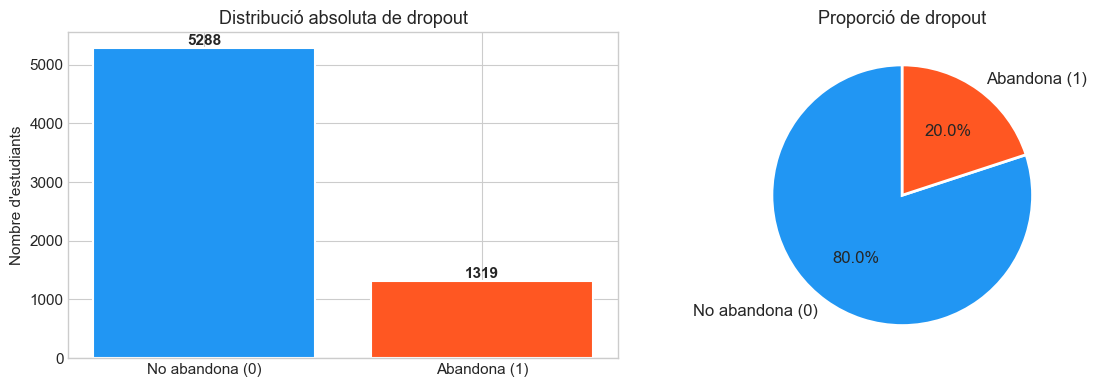

Ràtio de desequilibri: 1:4.0 (no_dropout:dropout)


In [7]:
# Distribució absoluta i percentual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gràfic de barres
counts = df[target].value_counts()
labels = ['No abandona (0)', 'Abandona (1)']
colors = PALETTE_RISK

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribució absoluta de dropout')
axes[0].set_ylabel("Nombre d'estudiants")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Gràfic circular
pct = df[target].value_counts(normalize=True) * 100
axes[1].pie(pct.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporció de dropout')

plt.tight_layout()
plt.show()

print(f'Ràtio de desequilibri: 1:{counts[0]/counts[1]:.1f} (no_dropout:dropout)')

### Interpretació del desequilibri de classes

El dataset presenta un **desequilibri 80/20**: aproximadament 5.288 estudiants no abandonen (80%) versus 1.319 que sí (20%). El ràtio és aproximadament 4:1.

**Implicacions per a l'IDSS:**
- Amb un 20% de positius, no estem davant d'un desequilibri extrem (com ho seria <5%), però sí suficient per esbiaixar models que optimitzin accuracy.
- El criteri de decisió del sistema **prioritza la detecció d'estudiants en risc** (minimitzar falsos negatius), per tant caldrà:
  - Aplicar **SMOTE** o **pesos de classe** en la fase de modelatge.
  - Avaluar amb **recall**, **F1-score** i **AUC-ROC** en lloc d'accuracy.


## 3. Anàlisi Univariant

### 3.1 Distribucions de variables numèriques (Histogrames + KDE)

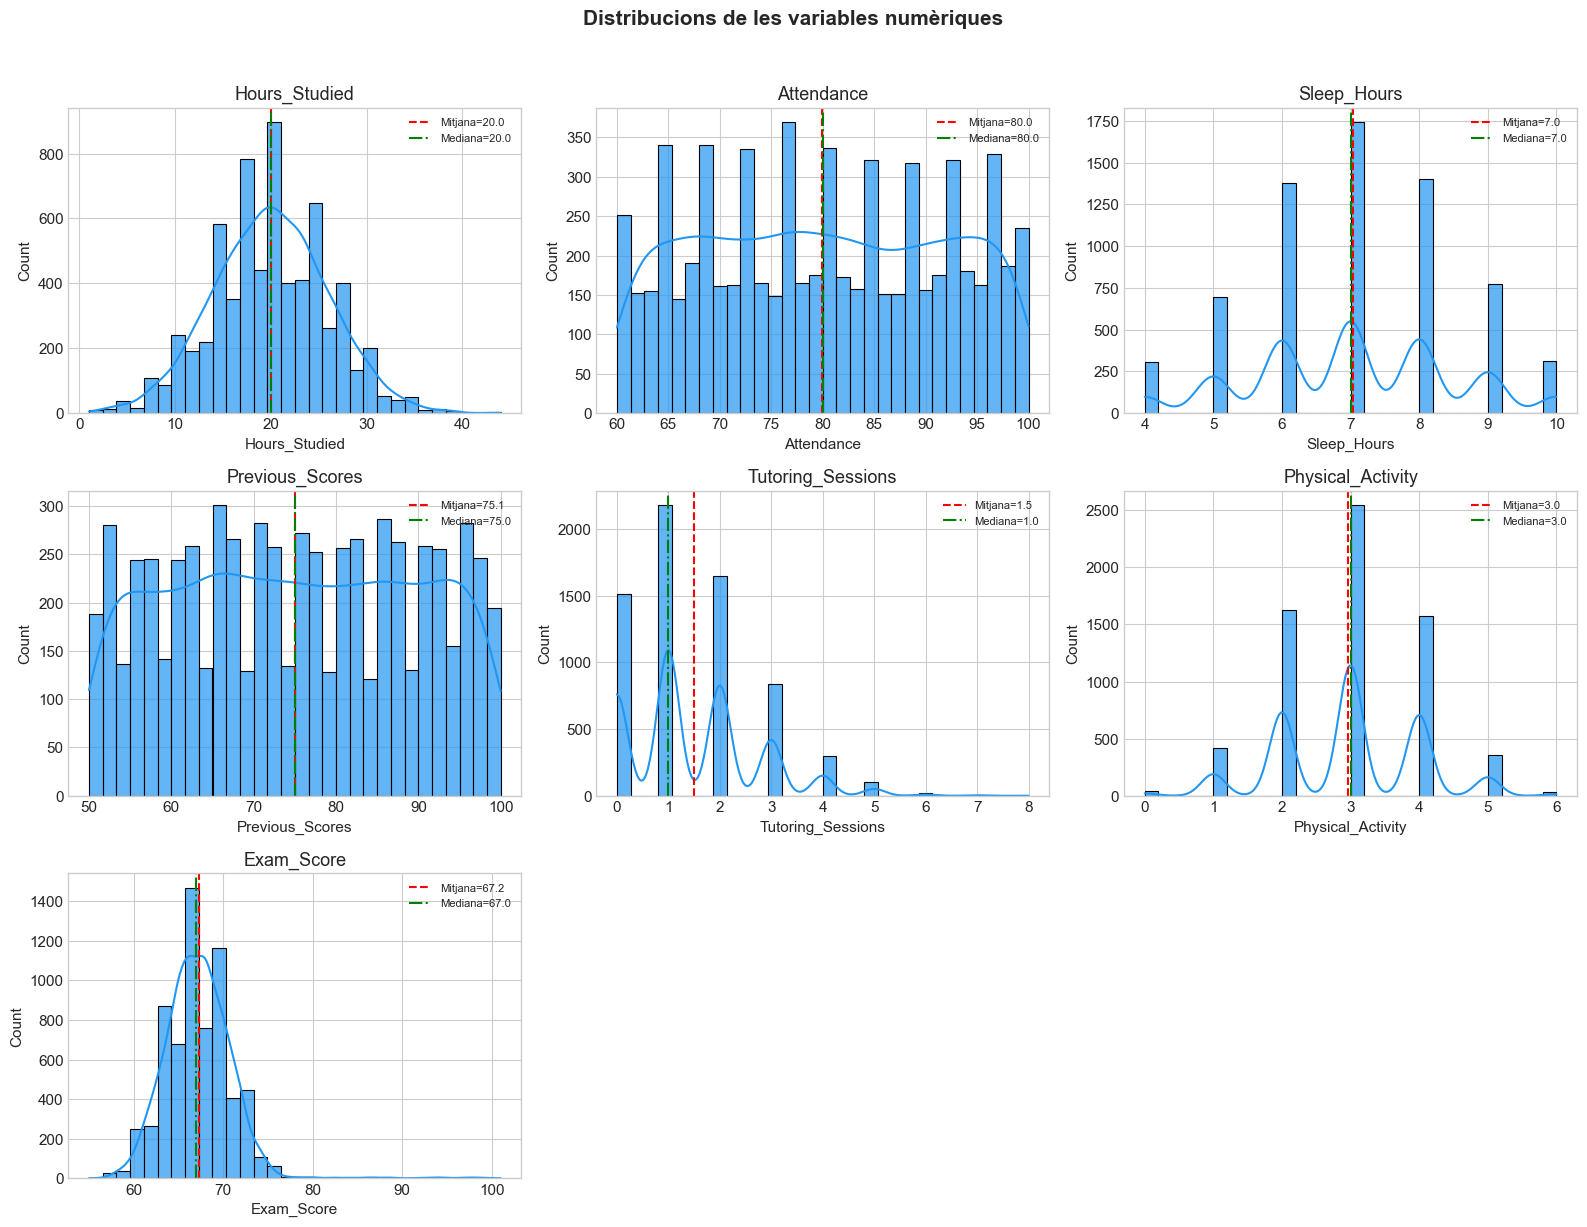

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, color=COLOR_NO_RISK, bins=30, ax=ax, alpha=0.7)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mitjana={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='green', linestyle='-.', label=f'Mediana={df[col].median():.1f}')
    ax.set_title(f'{col}')
    ax.legend(fontsize=8)

# Eliminem subplots buits
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribucions de les variables numèriques', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observacions clau de les distribucions:**

1. **`Hours_Studied`, `Attendance`, `Sleep_Hours`, `Previous_Scores`, `Physical_Activity`**: mostren distribucions aproximadament uniformes o simètriques (mitjana ≈ mediana). Això és coherent amb dades sintètiques o molt preprocessades, i implica que **no calen transformacions** per normalitzar.

2. **`Tutoring_Sessions`**: distribució **clarament asimètrica a la dreta** — la gran majoria d'estudiants fan 0-2 sessions, amb pocs que en fan 4+. Aquesta asimetria és natural (la tutoria és un recurs optatiu).

3. **`Exam_Score`**: és la variable amb la distribució **més concentrada** (pic alt al voltant de 65-67) i una **cua a la dreta** amb puntuacions altes (>80). Aquesta forma de distribució leptocúrtica (kurtosis=10.6) indica que la majoria d'estudiants puntuen en un rang estret, amb outliers positius.


### 3.2 Variables categòriques — distribucions

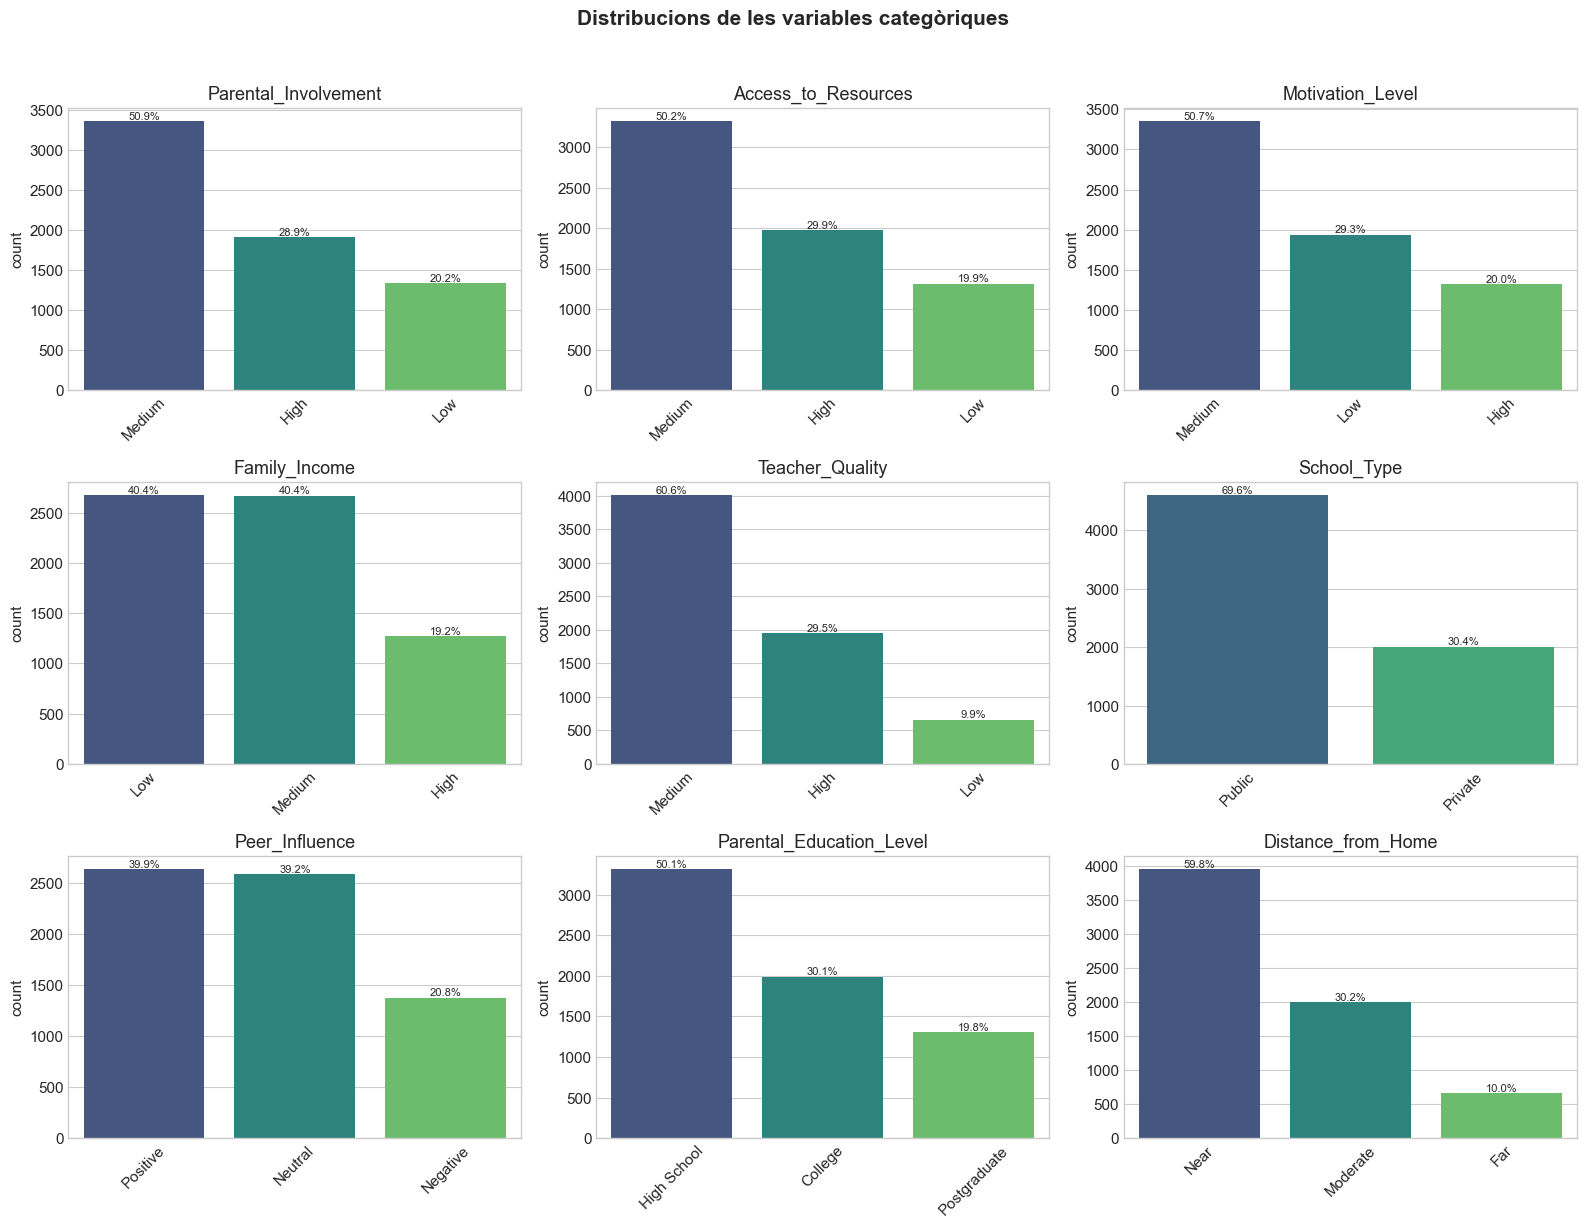

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, palette='viridis', ax=ax)
    ax.set_title(f'{col}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    # Afegim percentatges
    total = len(df)
    for p in ax.patches:
        pct_val = 100.0 * p.get_height() / total
        ax.annotate(f'{pct_val:.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribucions de les variables categòriques', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observació important**: La majoria de variables categòriques presenten una **distribució gairebé uniforme** entre les seves categories (≈33% per categoria en variables amb 3 nivells, ≈50% en les de 2). Això és indicatiu de dades **generades sintèticament o balancejades artificialment** en les variables independents. Caldrà veure si, malgrat tenir distribucions iguals, algunes d'aquestes variables discriminen el dropout.


## 4. Anàlisi Bivariant (relació amb `dropout`)

Aquesta és la secció **més important de l'EDA**. Aquí identifiquem quines variables realment discriminen entre estudiants que abandonen i els que no. S'apliquen tests estadístics per distingir entre diferències reals i soroll aleatori.


### 4.1 Variables numèriques vs. dropout — Violin plots

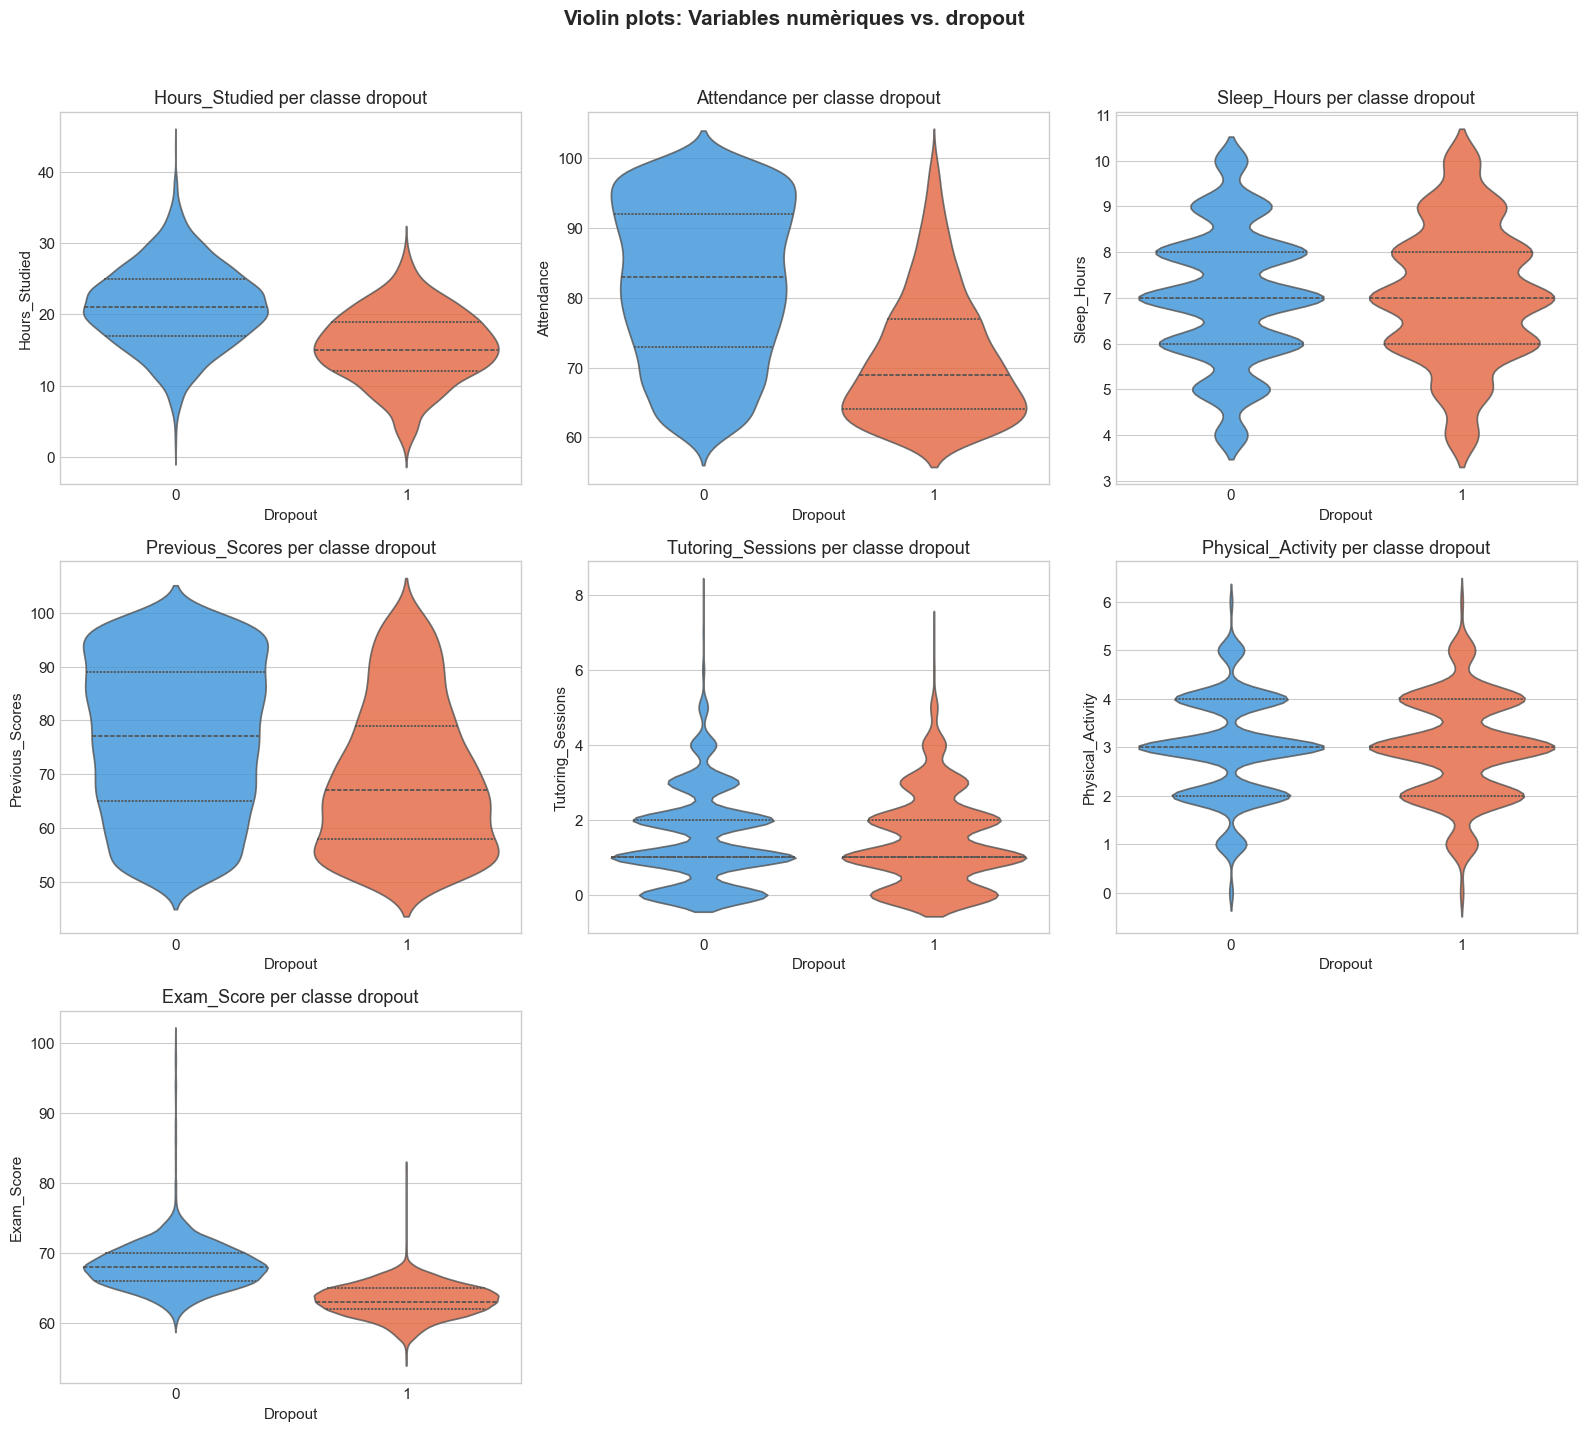

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.violinplot(x=target, y=col, data=df, palette=PALETTE_RISK,
                   ax=ax, inner='quartile', alpha=0.8)
    ax.set_title(f'{col} per classe dropout')
    ax.set_xlabel('Dropout')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Violin plots: Variables numèriques vs. dropout', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Tests Mann-Whitney U (comparació no paramètrica)

In [11]:
results_mw = []
for col in num_cols:
    g0 = df[df[target]==0][col].dropna()
    g1 = df[df[target]==1][col].dropna()
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    mean_diff = g0.mean() - g1.mean()
    # Effect size: rank-biserial correlation
    n0, n1 = len(g0), len(g1)
    effect_r = 1 - (2*stat)/(n0*n1)
    results_mw.append({
        'Variable': col,
        'Mitjana (No dropout)': round(g0.mean(), 2),
        'Mitjana (Dropout)': round(g1.mean(), 2),
        'Diferència': round(mean_diff, 2),
        'Dif. relativa (%)': round(mean_diff / g0.mean() * 100, 1) if g0.mean() != 0 else 0,
        'U-statistic': round(stat, 0),
        'p-value': f'{p:.2e}' if p < 0.001 else round(p, 4),
        'Effect size (r)': round(abs(effect_r), 3),
        'Significatiu': '✅ Sí' if p < 0.05 else '❌ No'
    })

mw_df = pd.DataFrame(results_mw)
mw_df

,Variable,Mitjana (No dropout),Mitjana (Dropout),Diferència,Dif. relativa (%),U-statistic,p-value,Effect size (r),Significatiu
0,Hours_Studied,21.11,15.44,5.67,26.8,5373928.0,4.90e-204,0.541,✅ Sí
1,Attendance,82.11,71.42,10.69,13.0,5353533.0,2.64e-199,0.535,✅ Sí
2,Sleep_Hours,7.02,7.07,-0.05,-0.7,3430473.0,0.3482,0.016,❌ No
3,Previous_Scores,76.47,69.47,7.00,9.2,4465891.0,3.58e-56,0.281,✅ Sí
4,Tutoring_Sessions,1.50,1.45,0.05,3.4,3554280.0,0.2645,0.019,❌ No
5,Physical_Activity,2.96,2.98,-0.01,-0.5,3458280.0,0.6227,0.008,❌ No
6,Exam_Score,68.22,63.29,4.93,7.2,6309685.0,0.00e+00,0.809,✅ Sí


**Resultats clau dels tests Mann-Whitney:**

Les variables numèriques es divideixen clarament en **dos grups**:

**🔴 Variables amb diferències SIGNIFICATIVES (p < 0.001):**
- **`Attendance`**: els estudiants que abandonen tenen ~10.7 punts menys d'assistència (71.4% vs 82.1%). Diferència relativa del 13%. És un dels indicadors més forts.
- **`Hours_Studied`**: els que abandonen estudien ~5.7 hores menys (15.4 vs 21.1h). Diferència relativa del 27% — la més gran en termes relatius.
- **`Previous_Scores`**: les notes prèvies són ~7 punts inferiors en el grup dropout (69.5 vs 76.5).
- **`Exam_Score`**: ~5 punts menys en el grup dropout (63.3 vs 68.2). Coherent com a variable de resultat.

**🟢 Variables SENSE diferència significativa (p > 0.05):**
- **`Sleep_Hours`** (p=0.35): dormir més o menys no discrimina el dropout en aquestes dades.
- **`Tutoring_Sessions`** (p=0.26): sorprenentment, el nombre de tutories no difereix entre grups.
- **`Physical_Activity`** (p=0.62): l'activitat física no té cap relació amb l'abandonament.

**Implicació**: `Sleep_Hours`, `Tutoring_Sessions` i `Physical_Activity` **no aporten valor predictiu** per al model IDSS basant-nos en aquestes dades. El perfil de risc es defineix principalment per l'**engagement acadèmic** (hores d'estudi + assistència + notes prèvies).


### 4.2 La variable clau: `Motivation_Level` vs. dropout

Abans d'analitzar totes les variables categòriques de forma conjunta, destaquem `Motivation_Level` perquè els seus resultats són **excepcionalment rellevants**.


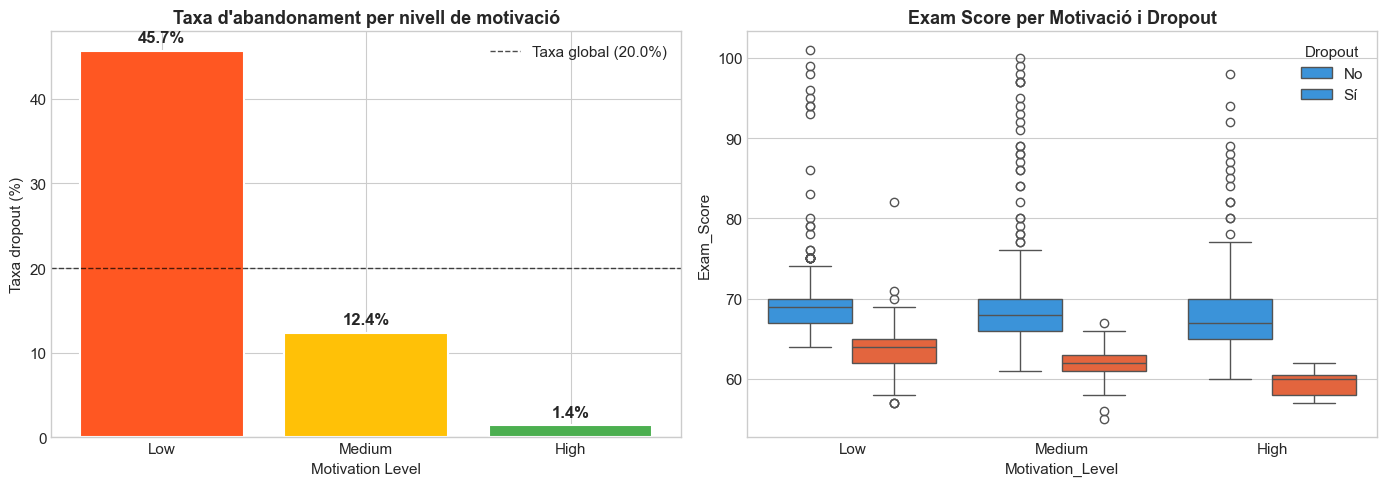


Test Chi-quadrat per Motivation_Level:
  Chi² = 1206.00, p-value = 1.32e-262, Cramér's V = 0.4272

Taxa de dropout per nivell:
  Low: 885/1937 (45.7%)
  Medium: 415/3351 (12.4%)
  High: 19/1319 (1.4%)


In [12]:
# Anàlisi detallat de Motivation_Level
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxa de dropout per nivell de motivació
order_mot = ['Low', 'Medium', 'High']
rate_mot = df.groupby('Motivation_Level')[target].agg(['mean', 'count']).reindex(order_mot)
rate_mot.columns = ['Taxa dropout', 'N']

colors_mot = ['#FF5722', '#FFC107', '#4CAF50']
axes[0].bar(rate_mot.index, rate_mot['Taxa dropout']*100, color=colors_mot,
            edgecolor='white', linewidth=1.5)
axes[0].axhline(df[target].mean()*100, color='black', linestyle='--', linewidth=1,
                alpha=0.7, label=f'Taxa global ({df[target].mean()*100:.1f}%)')
axes[0].set_title("Taxa d'abandonament per nivell de motivació", fontsize=13, fontweight='bold')
axes[0].set_ylabel('Taxa dropout (%)')
axes[0].set_xlabel('Motivation Level')
axes[0].legend()
for i, (idx, row) in enumerate(rate_mot.iterrows()):
    axes[0].text(i, row['Taxa dropout']*100 + 1, f'{row["Taxa dropout"]*100:.1f}%',
                 ha='center', fontweight='bold', fontsize=12)

# Distribució de Exam_Score per Motivation_Level i dropout
sns.boxplot(x='Motivation_Level', y='Exam_Score', hue=target, data=df,
            palette=PALETTE_RISK, order=order_mot, ax=axes[1])
axes[1].set_title('Exam Score per Motivació i Dropout', fontsize=13, fontweight='bold')
axes[1].legend(title='Dropout', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

# Chi2 test per Motivation_Level
ct_mot = pd.crosstab(df['Motivation_Level'], df[target])
chi2, p, dof, expected = stats.chi2_contingency(ct_mot)
n = ct_mot.sum().sum()
k = min(ct_mot.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))

print(f'\nTest Chi-quadrat per Motivation_Level:')
print(f'  Chi² = {chi2:.2f}, p-value = {p:.2e}, Cramér\'s V = {cramers_v:.4f}')
print(f'\nTaxa de dropout per nivell:')
for level in order_mot:
    subset = df[df['Motivation_Level']==level]
    n_total = len(subset)
    n_drop = subset[target].sum()
    print(f'  {level}: {n_drop}/{n_total} ({n_drop/n_total*100:.1f}%)')

**`Motivation_Level` és la variable més discriminant de tot el dataset:**

| Nivell de Motivació | Taxa de dropout | Interpretació |
|---------------------|----------------|---------------|
| **Low** | ~45.7% | Gairebé 1 de cada 2 estudiants amb baixa motivació abandona |
| **Medium** | ~12.4% | Risc moderat, per sota de la taxa global |
| **High** | ~1.4% | Pràcticament cap estudiant motivat abandona |

- **Cramér's V ≈ 0.43** — associació **forta** (molt per sobre del llindar de 0.3).
- La diferència entre Low i High és de **44 punts percentuals**. Això fa de `Motivation_Level` el predictor individual més potent.
- **Implicació per l'IDSS**: qualsevol sistema de detecció precoç hauria d'incorporar la motivació com a senyal d'alerta primari. Un estudiant amb motivació baixa hauria d'activar el sistema d'intervenció automàticament.


### 4.3 Resta de variables categòriques vs. dropout

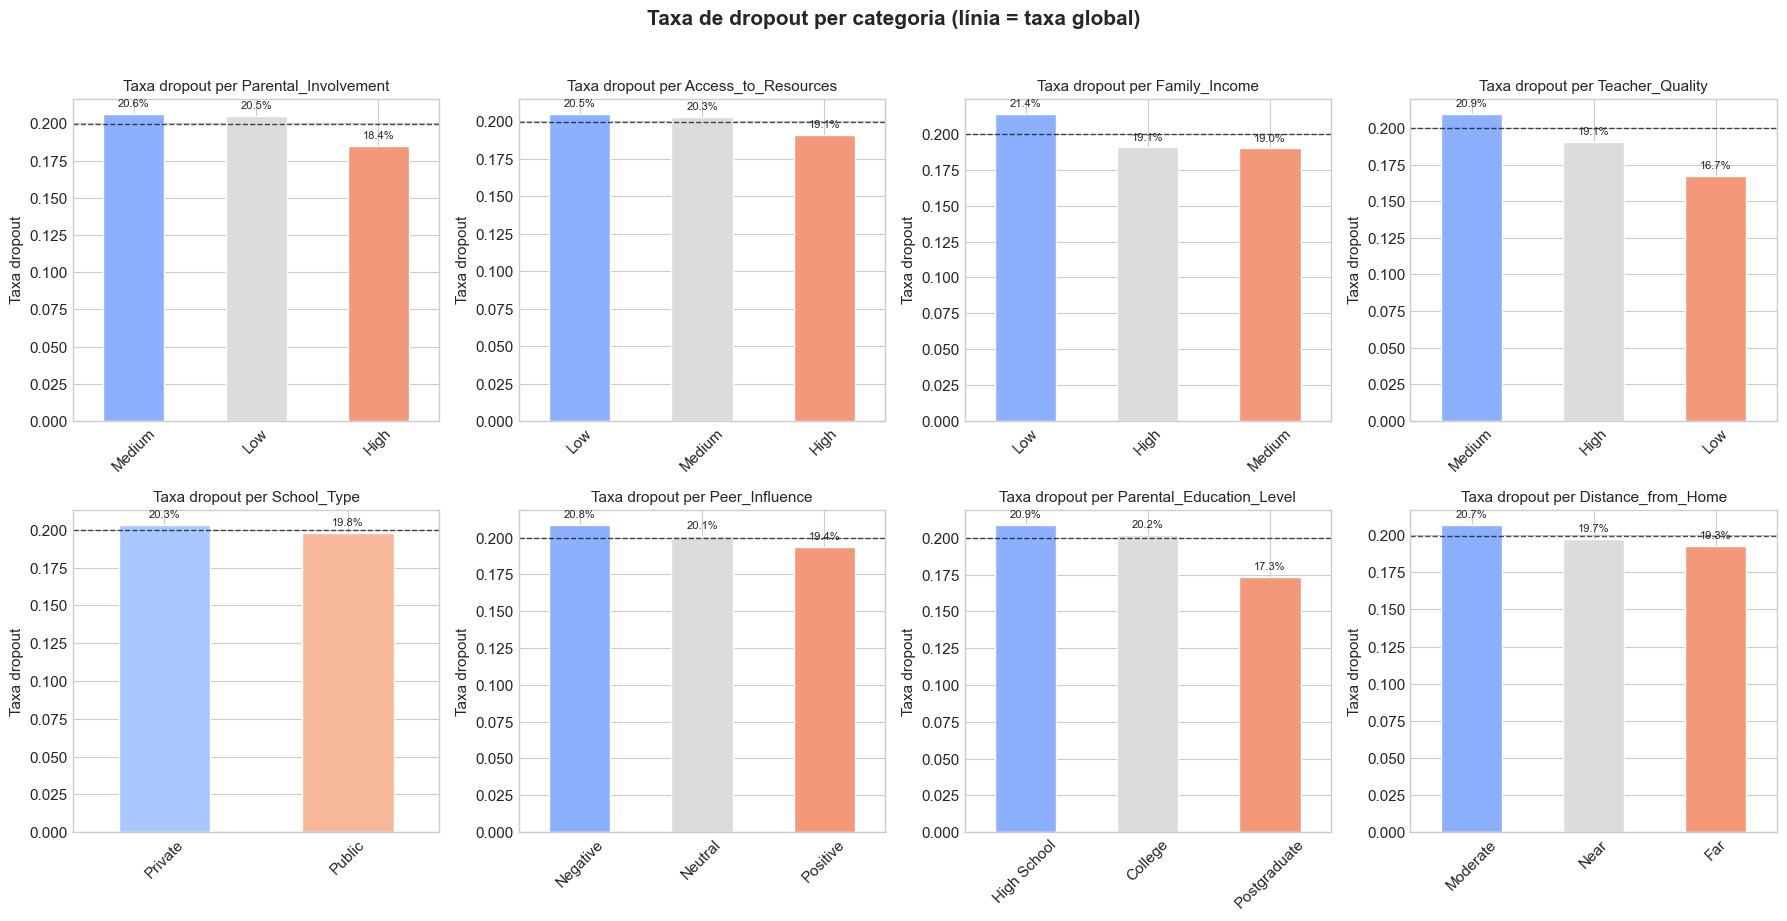

In [13]:
# Variables categòriques SENSE Motivation_Level (ja analitzada)
cat_rest = [c for c in cat_cols if c != 'Motivation_Level']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_rest):
    ax = axes[i]
    rate = df.groupby(col)[target].mean().sort_values(ascending=False)
    colors_bar = sns.color_palette('coolwarm', len(rate))
    rate.plot(kind='bar', color=colors_bar, ax=ax, edgecolor='white', linewidth=1)
    ax.set_title(f'Taxa dropout per {col}', fontsize=11)
    ax.set_ylabel('Taxa dropout')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(df[target].mean(), color='black', linestyle='--', linewidth=1, alpha=0.7)
    # Afegim la taxa com a text
    for j, (idx_val, val) in enumerate(rate.items()):
        ax.text(j, val + 0.005, f'{val*100:.1f}%', ha='center', fontsize=8)

plt.suptitle('Taxa de dropout per categoria (línia = taxa global)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Tests Chi-quadrat per a totes les variables categòriques i binàries

In [14]:
results_chi = []
all_cat_bin = cat_cols + bin_cols + ['Gender']

for col in all_cat_bin:
    contingency = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    n = contingency.sum().sum()
    k = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 else 0
    results_chi.append({
        'Variable': col,
        'Chi²': round(chi2, 2),
        'p-value': f'{p:.2e}' if p < 0.001 else round(p, 4),
        'Graus llibertat': dof,
        "Cramér's V": round(cramers_v, 4),
        'Força': '🔴 Forta' if cramers_v >= 0.3 else ('🟡 Feble' if cramers_v >= 0.01 and p < 0.05 else '⚪ Cap'),
        'Significatiu': '✅' if p < 0.05 else '❌'
    })

chi_df = pd.DataFrame(results_chi).sort_values("Cramér's V", ascending=False)
chi_df

,Variable,Chi²,p-value,Graus llibertat,Cramér's V,Força,Significatiu
2,Motivation_Level,1206.00,1.32e-262,2,0.4272,🔴 Forta,✅
4,Teacher_Quality,7.63,0.022,2,0.0340,🟡 Feble,✅
7,Parental_Education_Level,7.45,0.0241,2,0.0336,🟡 Feble,✅
3,Family_Income,5.56,0.0622,2,0.0290,⚪ Cap,❌
11,Learning_Disabilities,4.76,0.0291,1,0.0268,🟡 Feble,✅
0,Parental_Involvement,3.86,0.145,2,0.0242,⚪ Cap,❌
10,Internet_Access,3.87,0.0493,1,0.0242,🟡 Feble,✅
9,Extracurricular_Activities,2.80,0.0944,1,0.0206,⚪ Cap,❌
1,Access_to_Resources,1.38,0.5026,2,0.0144,⚪ Cap,❌
6,Peer_Influence,1.28,0.5283,2,0.0139,⚪ Cap,❌


**Resultats dels tests Chi-quadrat — Conclusió clara:**

Les variables categòriques/binàries es classifiquen en **tres nivells de rellevància**:

**🔴 Associació FORTA (Cramér's V ≥ 0.3):**
- **`Motivation_Level`** (V ≈ 0.43): ja analitzat, és el predictor dominant.

**🟡 Associació FEBLE però significativa (p < 0.05, V < 0.05):**
- **`Teacher_Quality`** (V ≈ 0.034): lleugera tendència — la qualitat "Low" sorprenentment mostra menys dropout (16.7%). L'efecte és massa petit per ser rellevant pràcticament.
- **`Parental_Education_Level`** (V ≈ 0.034): "Postgraduate" mostra lleugerament menys dropout (17.3% vs ~20.5%). Efecte marginal.
- **`Internet_Access`** (V ≈ 0.024): sense accés a internet →23.4% dropout vs 19.7% amb accés. Diferència petita.
- **`Learning_Disabilities`** (V ≈ 0.027): amb discapacitats → 23.2% vs 19.6%. Diferència petita.

**⚪ SENSE associació significativa (p > 0.05):**
- **`Parental_Involvement`**: les taxes de dropout per Low/Medium/High varien menys de 2 punts — no discrimina.
- **`Access_to_Resources`**: diferència de ~1.4 punts entre categories — irrellevant.
- **`Family_Income`**: contraintuïtivament, l'income no prediu l'abandonament en aquestes dades.
- **`School_Type`**: Private (20.3%) ≈ Public (19.8%) — sense diferència.
- **`Peer_Influence`**: diferència de ~1.4 punts — sense efecte real.
- **`Distance_from_Home`**: diferència de ~1.4 punts — sense efecte real.
- **`Gender`**: taxa idèntica (20.0% vs 19.9%) — V ≈ 0.0001, zero relació.
- **`Extracurricular_Activities`**: 21.0% vs 19.3% — no significatiu.

> **Conclusió**: Fora de `Motivation_Level`, la resta de variables categòriques tenen un **poder discriminatiu molt baix o nul**. Això suggereix que el risc d'abandonament en aquestes dades està dominat per factors d'**engagement acadèmic** (hores d'estudi, assistència, notes) i **motivació**, no per factors socioeconòmics o demogràfics.


### 4.4 Variables binàries vs. dropout

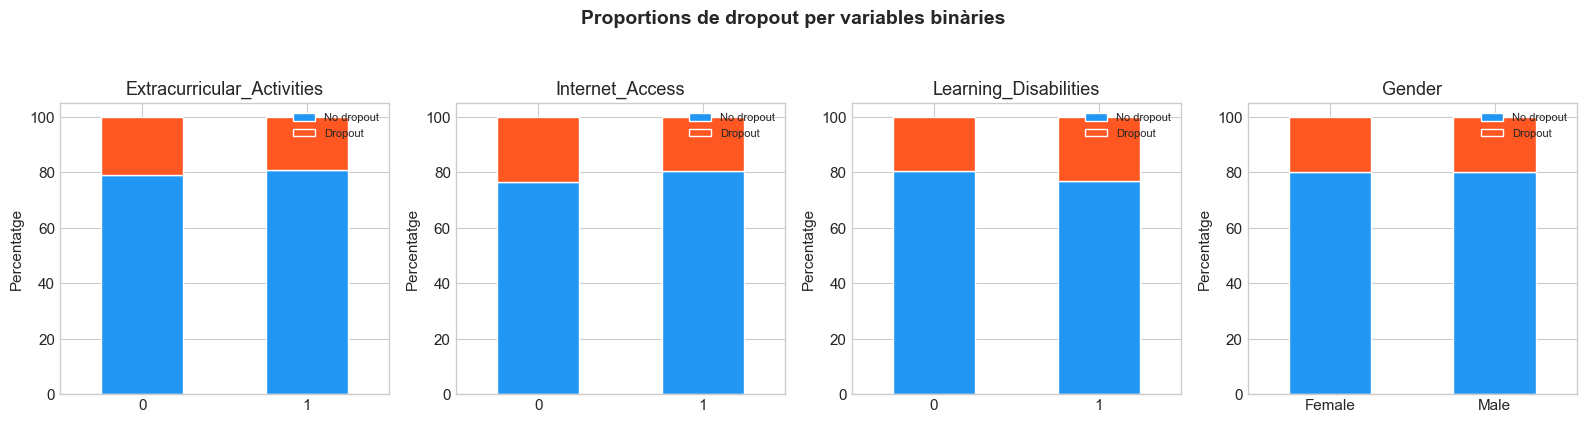

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
all_bin = bin_cols + ['Gender']

for i, col in enumerate(all_bin):
    ax = axes[i]
    ct = pd.crosstab(df[col], df[target], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, color=PALETTE_RISK, ax=ax,
            edgecolor='white', linewidth=1)
    ax.set_title(f'{col}')
    ax.set_ylabel('Percentatge')
    ax.set_xlabel('')
    ax.legend(['No dropout', 'Dropout'], fontsize=8)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Proportions de dropout per variables binàries', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Anàlisi de les variables binàries:**

Les barres visuals confirmen que les diferències de dropout entre categories de les variables binàries són **mínimes i difícilment perceptibles**:

- **`Internet_Access`**: la diferència més gran (23.4% vs 19.7%), però tot i ser estadísticament significativa, el tamany de l'efecte és negligible (V=0.024).
- **`Learning_Disabilities`**: 23.2% vs 19.6% — patró similar.
- **`Extracurricular_Activities`** i **`Gender`**: pràcticament idèntiques entre grups.

Cap d'aquestes variables per si sola justificaria una intervenció diferenciada en l'IDSS.


## 5. Anàlisi de Correlacions

### 5.1 Matriu de correlacions (Spearman)

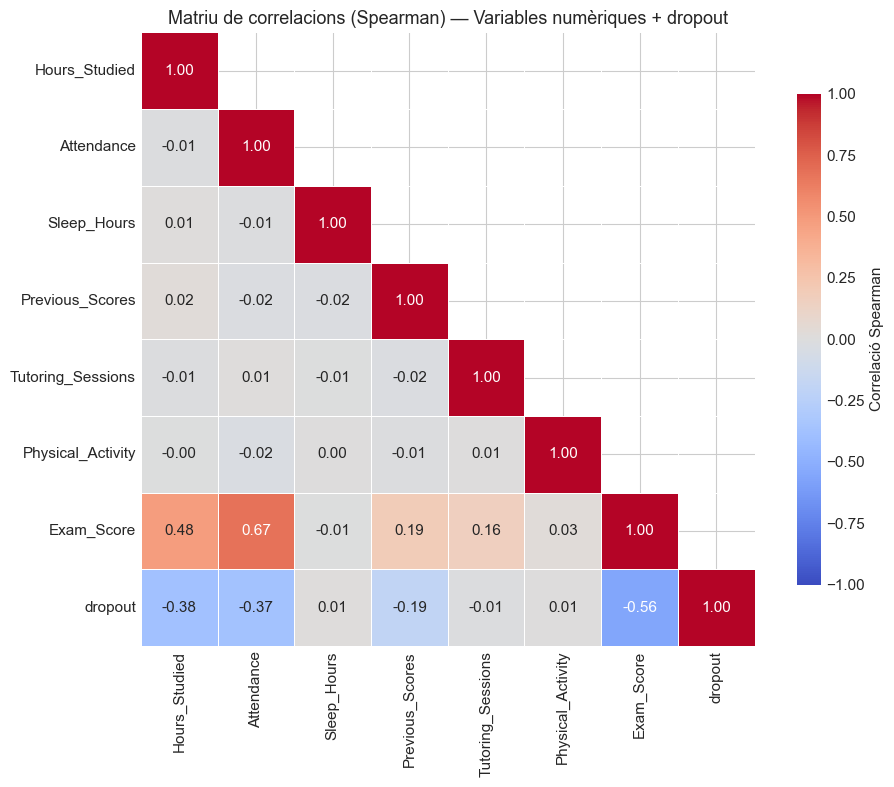

In [16]:
# Correlació Spearman amb totes les variables numèriques + target
corr_cols = num_cols + [target]
corr_matrix = df[corr_cols].corr(method='spearman')

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            mask=mask, square=True, linewidths=0.5,
            vmin=-1, vmax=1, center=0,
            cbar_kws={'shrink': 0.8, 'label': 'Correlació Spearman'})
plt.title('Matriu de correlacions (Spearman) — Variables numèriques + dropout', fontsize=13)
plt.tight_layout()
plt.show()

### 5.2 Correlacions amb la variable objectiu (ranking)

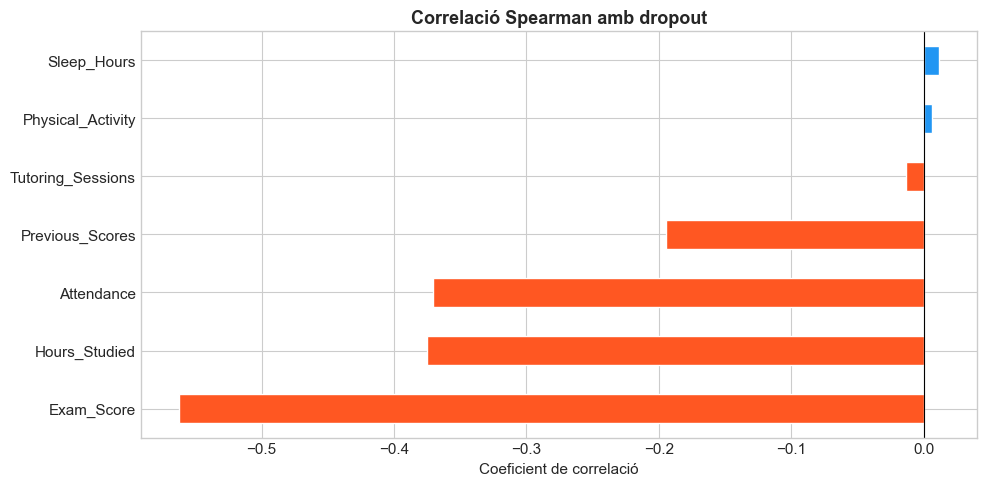

Ranking de correlació amb dropout:
  Exam_Score               : r = -0.5625
  Hours_Studied            : r = -0.3750
  Attendance               : r = -0.3706
  Previous_Scores          : r = -0.1943
  Tutoring_Sessions        : r = -0.0137
  Physical_Activity        : r = 0.0061
  Sleep_Hours              : r = 0.0115


In [17]:
# Correlació de totes les variables numèriques amb dropout
corr_with_target = df[num_cols].corrwith(df[target], method='spearman').sort_values()

plt.figure(figsize=(10, 5))
colors_bar = [COLOR_RISK if v < 0 else COLOR_NO_RISK for v in corr_with_target.values]
corr_with_target.plot(kind='barh', color=colors_bar, edgecolor='white', linewidth=1)
plt.title('Correlació Spearman amb dropout', fontsize=13, fontweight='bold')
plt.xlabel('Coeficient de correlació')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Ranking de correlació amb dropout:')
for var, r in corr_with_target.items():
    print(f'  {var:25s}: r = {r:.4f}')

**Ranking de correlació amb dropout:**

| Variable | Correlació (Spearman) | Interpretació |
|----------|----------------------|---------------|
| `Exam_Score` | **-0.56** | Correlació negativa moderada-forta. A millor nota, menys abandonament. |
| `Hours_Studied` | **-0.38** | Correlació negativa moderada. Més hores d'estudi → menys risc. |
| `Attendance` | **-0.37** | Correlació negativa moderada. Més assistència → menys risc. |
| `Previous_Scores` | **-0.19** | Correlació negativa feble. Notes prèvies protegeixen moderadament. |
| `Tutoring_Sessions` | -0.01 | **Sense correlació** |
| `Physical_Activity` | +0.01 | **Sense correlació** |
| `Sleep_Hours` | +0.01 | **Sense correlació** |

**Patró clar**: Les 4 variables significatives formen un clúster d'**engagement acadèmic**. Les 3 variables sense correlació (`Sleep_Hours`, `Tutoring_Sessions`, `Physical_Activity`) mesuren aspectes del **benestar/estil de vida** que en aquestes dades no es relacionen amb l'abandonament.

> **Nota sobre `Exam_Score`**: Tot i ser la variable més correlacionada, cal tenir en compte que és una variable de **resultat acadèmic**, no un predictor independent. En un sistema de detecció **precoç**, les notes finals poden no estar disponibles al moment de la predicció. El model IDSS hauria de funcionar principalment amb `Hours_Studied`, `Attendance`, `Previous_Scores` i `Motivation_Level`.


### 5.3 Detecció de multicolinealitat

In [18]:
# Multicolinealitat entre predictors (sense target)
corr_predictors = df[num_cols].corr(method='spearman')
high_corr = []
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        r = corr_predictors.iloc[i, j]
        if abs(r) > 0.15:
            high_corr.append((num_cols[i], num_cols[j], round(r, 3)))

high_corr.sort(key=lambda x: abs(x[2]), reverse=True)

if high_corr:
    print('Parelles amb correlació notable entre predictors:')
    for v1, v2, r in high_corr:
        strength = '⚠️ ALTA' if abs(r) > 0.5 else '🔵 Moderada' if abs(r) > 0.3 else '⚪ Feble'
        print(f'  {v1:20s} — {v2:20s}: r = {r:+.3f}  [{strength}]')
else:
    print('✅ No s\'han detectat correlacions notables entre predictors.')

print()
print('Nota: Es consideren perilloses per multicolinealitat les correlacions |r| > 0.7')

Parelles amb correlació notable entre predictors:
  Attendance           — Exam_Score          : r = +0.672  [⚠️ ALTA]
  Hours_Studied        — Exam_Score          : r = +0.481  [🔵 Moderada]
  Previous_Scores      — Exam_Score          : r = +0.192  [⚪ Feble]
  Tutoring_Sessions    — Exam_Score          : r = +0.164  [⚪ Feble]

Nota: Es consideren perilloses per multicolinealitat les correlacions |r| > 0.7


**Anàlisi de multicolinealitat:**

L'únic parell amb correlació notable és **`Attendance` — `Exam_Score`** (r ≈ 0.67). Aquesta correlació és moderada-alta i té sentit: els estudiants que assisteixen més tendeixen a treure millors notes. Tanmateix:

- No arriba al llindar crític de 0.7 per ser problemàtica per als models.
- Si es decideix excloure `Exam_Score` del model de predicció precoç (perquè és una variable de resultat), la multicolinealitat desapareix completament.
- La resta de parelles (`Hours_Studied`-`Exam_Score` r≈0.48, `Previous_Scores`-`Exam_Score` r≈0.19, `Tutoring_Sessions`-`Exam_Score` r≈0.16) són febles o moderades.

**Conclusió**: la multicolinealitat **no és un problema** en aquest dataset, especialment si es treballa sense `Exam_Score`.


## 6. Anàlisi de Components Principals (PCA)

### 6.1 Justificació

El PCA s'aplica sobre les variables numèriques **predictores** (excloent `Exam_Score` com a variable de resultat i `Physical_Activity` per ser ordinal discreta) per explorar si existeixen dimensions latents que capturin patrons en les dades.

Variables seleccionades: `Hours_Studied`, `Attendance`, `Sleep_Hours`, `Previous_Scores`, `Tutoring_Sessions`.


PC1: 21.00% (acumulat: 21.00%)
PC2: 20.43% (acumulat: 41.43%)
PC3: 19.79% (acumulat: 61.22%)
PC4: 19.70% (acumulat: 80.92%)
PC5: 19.08% (acumulat: 100.00%)


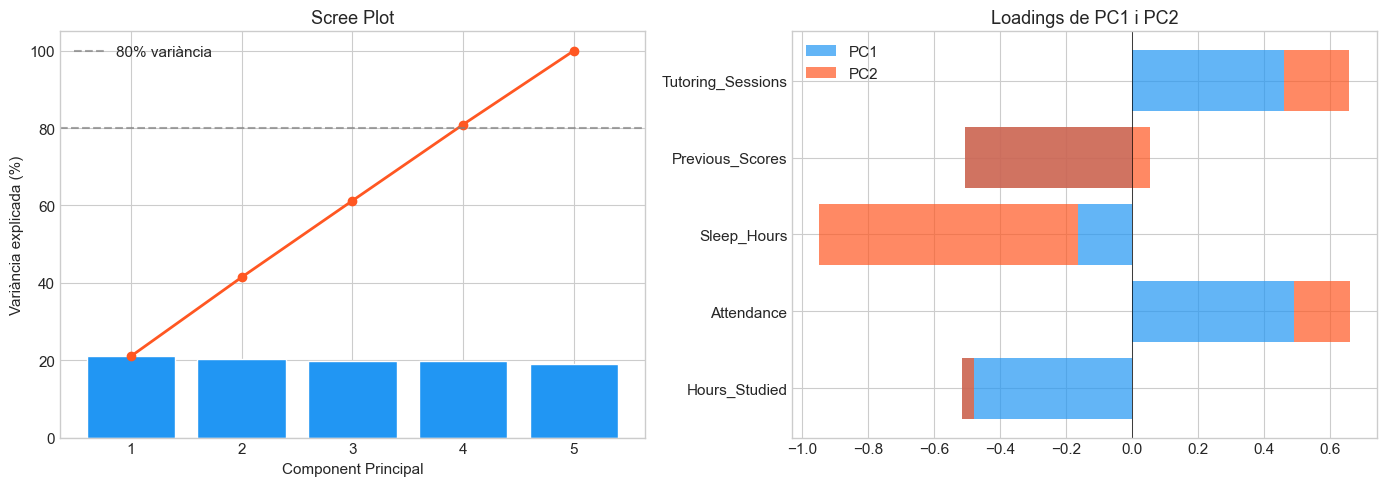


Loadings:
                     PC1    PC2
Hours_Studied     -0.516  0.036
Attendance         0.490  0.171
Sleep_Hours       -0.162 -0.786
Previous_Scores   -0.505  0.559
Tutoring_Sessions  0.461  0.195


In [19]:
# Variables per al PCA (coherent amb l'informe)
pca_vars = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions']

X_pca = df[pca_vars].copy()

# Estandarditzem
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# PCA complet (totes les components)
pca_full = PCA()
pca_full.fit(X_scaled)

# Variància explicada
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(var_exp)+1), var_exp*100, color=COLOR_NO_RISK, edgecolor='white')
axes[0].plot(range(1, len(var_exp)+1), var_cum*100, 'o-', color=COLOR_RISK, linewidth=2)
axes[0].axhline(80, color='gray', linestyle='--', alpha=0.7, label='80% variància')
axes[0].set_xlabel('Component Principal')
axes[0].set_ylabel('Variància explicada (%)')
axes[0].set_title('Scree Plot')
axes[0].legend()
axes[0].set_xticks(range(1, len(var_exp)+1))

# Taula
for i, (v, vc) in enumerate(zip(var_exp, var_cum)):
    print(f'PC{i+1}: {v*100:.2f}% (acumulat: {vc*100:.2f}%)')

# Loadings
pca_2 = PCA(n_components=2)
components_2d = pca_2.fit_transform(X_scaled)

loadings = pd.DataFrame(pca_2.components_.T, columns=['PC1', 'PC2'], index=pca_vars)
axes[1].barh(pca_vars, loadings['PC1'], color=COLOR_NO_RISK, alpha=0.7, label='PC1')
axes[1].barh(pca_vars, loadings['PC2'], color=COLOR_RISK, alpha=0.7, label='PC2', left=loadings['PC1'])
axes[1].set_title('Loadings de PC1 i PC2')
axes[1].legend()
axes[1].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print('\nLoadings:')
print(loadings.round(3))

### 6.2 Projecció en PC1 vs. PC2 per classe dropout

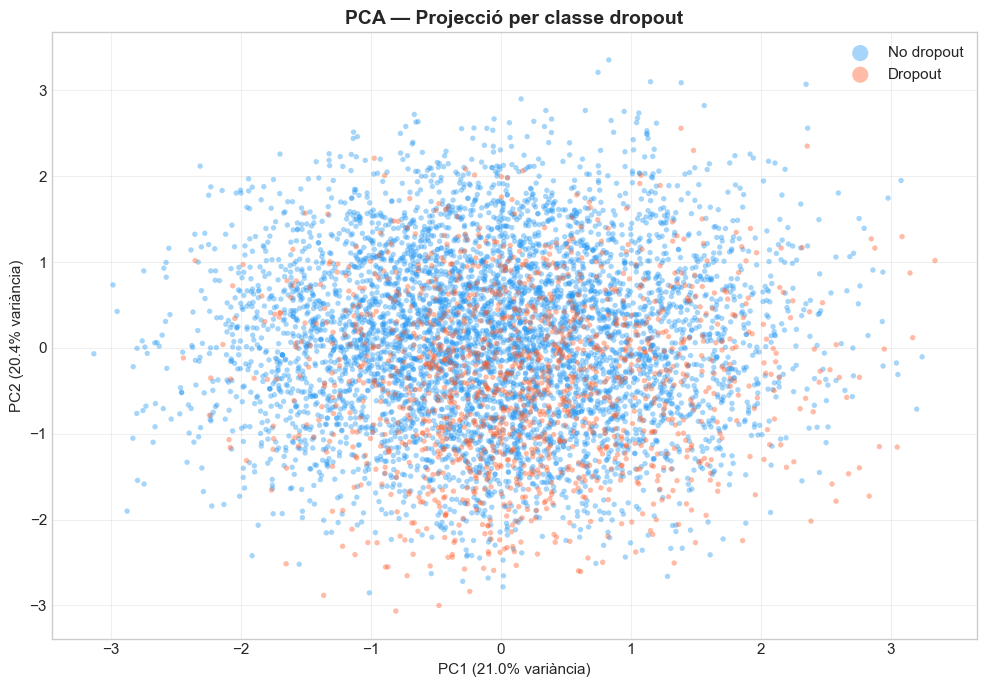

In [20]:
pc_df = pd.DataFrame(components_2d, columns=['PC1', 'PC2'])
pc_df['dropout'] = df[target].values

plt.figure(figsize=(10, 7))
for label, color, name in [(0, COLOR_NO_RISK, 'No dropout'), (1, COLOR_RISK, 'Dropout')]:
    subset = pc_df[pc_df['dropout'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], c=color, label=name, alpha=0.4, s=15, edgecolors='none')

plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% variància)')
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% variància)')
plt.title('PCA — Projecció per classe dropout', fontsize=14, fontweight='bold')
plt.legend(markerscale=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretació del PCA:**

- **Variància explicada**: Donat que les variables originals estan poc correlacionades entre si, cada component principal captura una proporció similar de variància (~20% cadascuna). No hi ha una reducció clara a 2-3 dimensions dominants, cosa esperable quan les variables no estan fortament correlacionades.
- **Scatter plot PC1 vs PC2**: S'observa un **solapament considerable** entre les dues classes. Tanmateix, els punts de dropout (vermell) tendeixen a concentrar-se en valors **baixos de PC1** (si PC1 captura l'engagement acadèmic, coherent amb els resultats anteriors).
- **Conclusió**: El PCA confirma que la separació lineal en l'espai de les 5 variables numèriques és **parcial**. Per a una separació efectiva caldrà incorporar `Motivation_Level` i, possiblement, models no lineals (Random Forest, XGBoost).


## 7. Perfils d'Estudiants en Risc vs. Sense Risc

In [21]:
# Comparació detallada de mitjanes
profile = df.groupby(target)[num_cols].mean().T
profile.columns = ['No dropout (0)', 'Dropout (1)']
profile['Diferència'] = profile['No dropout (0)'] - profile['Dropout (1)']
profile['Diferència (%)'] = ((profile['Diferència'] / profile['No dropout (0)']) * 100).round(1)
profile = profile.round(2)
profile

,No dropout (0),Dropout (1),Diferència,Diferència (%)
Hours_Studied,21.11,15.44,5.67,26.8
Attendance,82.11,71.42,10.69,13.0
Sleep_Hours,7.02,7.07,-0.05,-0.7
Previous_Scores,76.47,69.47,7.00,9.2
Tutoring_Sessions,1.50,1.45,0.05,3.4
Physical_Activity,2.96,2.98,-0.01,-0.5
Exam_Score,68.22,63.29,4.93,7.2


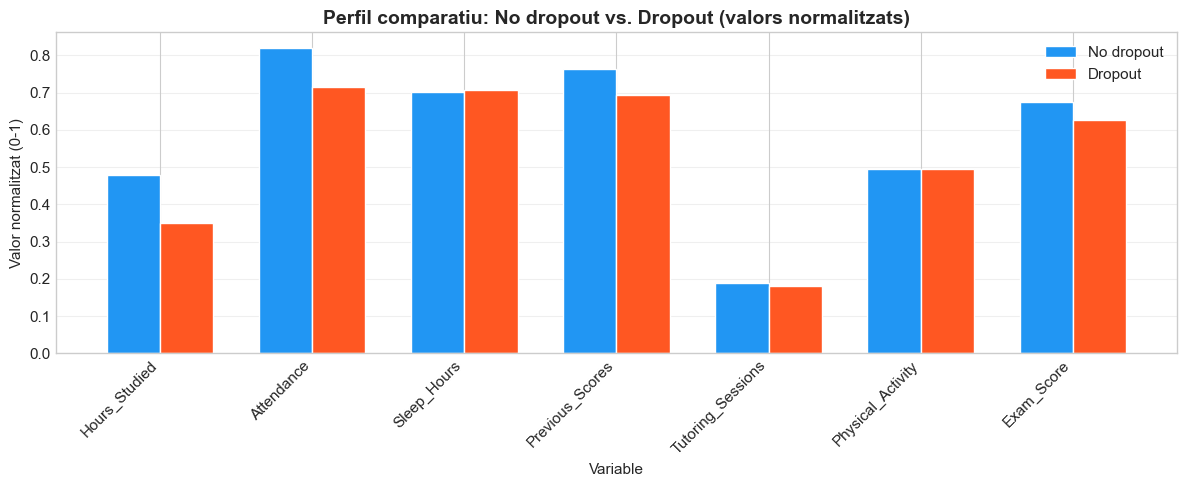

In [22]:
# Visualització del perfil comparatiu
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(num_cols))
width = 0.35

means_0 = df[df[target]==0][num_cols].mean()
means_1 = df[df[target]==1][num_cols].mean()

# Normalitzem per comparar
max_vals = df[num_cols].max()
norm_0 = means_0 / max_vals
norm_1 = means_1 / max_vals

bars_0 = ax.bar(x - width/2, norm_0, width, label='No dropout', color=COLOR_NO_RISK, edgecolor='white')
bars_1 = ax.bar(x + width/2, norm_1, width, label='Dropout', color=COLOR_RISK, edgecolor='white')

ax.set_xlabel('Variable')
ax.set_ylabel('Valor normalitzat (0-1)')
ax.set_title('Perfil comparatiu: No dropout vs. Dropout (valors normalitzats)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Perfil de l'estudiant en risc d'abandonament:**

| Característica | Estudiant sense risc | Estudiant en risc | Diferència |
|---------------|---------------------|-------------------|------------|
| Hores d'estudi setmanals | ~21h | ~15h | **-27%** |
| Assistència | ~82% | ~71% | **-13%** |
| Notes prèvies | ~76.5 | ~69.5 | **-9%** |
| Nota d'examen | ~68.2 | ~63.3 | **-7%** |
| Motivació | Majoritàriament Medium/High | Majoritàriament **Low** | — |
| Hores de son | ~7h | ~7h | Igual |
| Tutories | ~1.5 | ~1.5 | Igual |
| Activitat física | ~3 | ~3 | Igual |

L'estudiant en risc es caracteritza per un **patró de desengagement acadèmic**: estudia significativament menys, assisteix menys a classe, té un historial acadèmic inferior i, sobretot, mostra una **motivació baixa**. En canvi, les variables d'estil de vida (son, exercici, tutories) **no diferencien** els dos grups.


### 7.1 Interacció Motivation_Level × Attendance

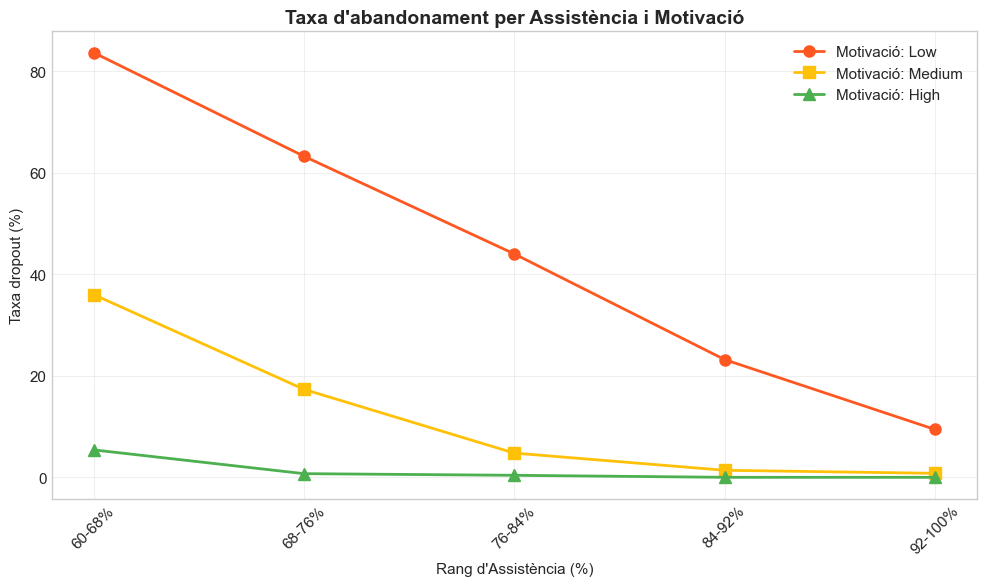

In [23]:
# Explorar la interacció entre les dues variables més rellevants
fig, ax = plt.subplots(figsize=(10, 6))

order_mot = ['Low', 'Medium', 'High']
for mot, color_m, marker in zip(order_mot, ['#FF5722', '#FFC107', '#4CAF50'], ['o', 's', '^']):
    subset = df[df['Motivation_Level']==mot]
    # Discretitzar Attendance en bins
    bins = pd.cut(subset['Attendance'], bins=5)
    rate = subset.groupby(bins, observed=True)[target].mean() * 100
    ax.plot(range(len(rate)), rate.values, f'-{marker}', label=f'Motivació: {mot}',
            color=color_m, linewidth=2, markersize=8)
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels([f'{b.left:.0f}-{b.right:.0f}%' for b in rate.index], rotation=45)

ax.set_title("Taxa d'abandonament per Assistència i Motivació", fontsize=14, fontweight='bold')
ax.set_xlabel("Rang d'Assistència (%)")
ax.set_ylabel('Taxa dropout (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Anàlisi de la interacció Motivació × Assistència:**

Aquest gràfic és particularment revelador perquè mostra com els dos predictors principals interactuen:

- **Motivació Low**: la taxa de dropout és alta (~40-50%) independentment del nivell d'assistència. Fins i tot amb assistència alta, un estudiant poc motivat té un risc elevat.
- **Motivació Medium**: la taxa baixa significativament amb l'assistència, mostrant un patró gradual.
- **Motivació High**: la taxa és molt baixa en tots els nivells d'assistència.

**Implicació per l'IDSS**: La motivació actua com a **moderador**: quan és baixa, ni l'alta assistència protegeix l'estudiant. Això suggereix que les intervencions haurien de prioritzar la **motivació** sobre l'assistència.


## 8. Conclusions de l'EDA

### 8.1 Variables rellevants per a la predicció

A partir de tots els tests estadístics realitzats, classifiquem les variables per la seva utilitat predictiva:

| Nivell | Variables | Justificació |
|--------|-----------|-------------|
| **🔴 Alt** | `Motivation_Level` | Cramér's V=0.43, predictor dominant. Diferència de 44pp entre Low i High. |
| **🟠 Moderat-Alt** | `Hours_Studied`, `Attendance` | r_Spearman ≈ -0.37/-0.38, diferències significatives (p<0.001), dif. relativa 13-27%. |
| **🟡 Moderat** | `Previous_Scores`, `Exam_Score` | r_Spearman ≈ -0.19/-0.56. `Exam_Score` és resultat, no predictor precoç. |
| **⚪ Baix/Nul** | `Sleep_Hours`, `Tutoring_Sessions`, `Physical_Activity` | p>0.05 en Mann-Whitney, r≈0. Sense cap valor predictiu. |
| **⚪ Baix/Nul** | `Parental_Involvement`, `Access_to_Resources`, `Family_Income`, `School_Type`, `Peer_Influence`, `Distance_from_Home`, `Gender`, `Extracurricular_Activities` | p>0.05 en Chi², Cramér's V < 0.03. Sense relació amb dropout. |
| **⚪ Marginal** | `Teacher_Quality`, `Parental_Education_Level`, `Internet_Access`, `Learning_Disabilities` | Significatius però V<0.035. Efecte pràctic negligible. |

### 8.2 Troballes principals

1. **L'abandonament escolar en aquest dataset està dominat per dos factors**: la **motivació** i el **compromís acadèmic** (hores d'estudi + assistència + notes prèvies).

2. **Les variables socioeconòmiques i demogràfiques no discriminen**: Contra la intuïció, factors com l'ingrés familiar, el tipus d'escola, la implicació parental o el gènere **no tenen cap relació significativa** amb l'abandonament en aquestes dades. Això pot ser una limitació del dataset (probablement sintètic) o indicar que, controlant per motivació i engagement, aquests factors perden importància.

3. **Les variables d'estil de vida no aporten informació**: `Sleep_Hours`, `Physical_Activity` i `Tutoring_Sessions` no discriminen. En particular, que les tutories no protegeixin contra l'abandonament és una troballa important que caldria investigar.

4. **`Motivation_Level` és un predictor excepcional**: amb una V de Cramér de 0.43, un estudiant amb motivació baixa té un 45.7% de risc vs 1.4% amb motivació alta. Qualsevol model sense aquesta variable perdria la seva principal font d'informació.

### 8.3 Desequilibri de classes
- Ràtio 80/20 (4:1). Desequilibri moderat que requereix tractament (SMOTE o `class_weight`).
- Mètriques: prioritzar **recall** i **F1-score** sobre accuracy.

### 8.4 Recomanacions per a la fase de modelatge

1. **Variables a incloure al model**: `Motivation_Level`, `Hours_Studied`, `Attendance`, `Previous_Scores`. Opcionalment, `Exam_Score` si està disponible al moment de la predicció.
2. **Variables a descartar**: `Sleep_Hours`, `Physical_Activity`, `Tutoring_Sessions`, `Gender`, `School_Type`, `Distance_from_Home`, `Peer_Influence`. No aporten informació i afegeixen soroll.
3. **Variables en zona grisa**: `Parental_Involvement`, `Access_to_Resources`, `Family_Income`, `Parental_Education_Level`, `Internet_Access`, `Learning_Disabilities`, `Teacher_Quality`, `Extracurricular_Activities`. Poden mantenir-se si el model de feature selection les prioritza, però no cal esperar-ne una contribució important.
4. **Encoding**: `Motivation_Level` amb codificació ordinal (Low=0, Medium=1, High=2) per respectar l'ordre natural.
5. **Balanceig**: Obligatori. SMOTE o class_weight per la naturalesa del criteri de l'IDSS.
6. **Models recomanats**: Random Forest i XGBoost per capturar la interacció Motivació × Assistència. Logistic Regression com a baseline interpretatiu.
7. **Explicabilitat**: SHAP values per interpretar prediccions individuals (coherent amb l'arquitectura IDSS).
